In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np

save_path = '/content/drive/MyDrive/road_data_numpy'

X_train = np.load(f'{save_path}/X_train.npy')
y_train = np.load(f'{save_path}/y_train.npy')
X_val   = np.load(f'{save_path}/X_val.npy')
y_val   = np.load(f'{save_path}/y_val.npy')
X_test  = np.load(f'{save_path}/X_test.npy')
y_test  = np.load(f'{save_path}/y_test.npy')

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

X_train: (460, 20, 64, 64, 3), y_train: (460,)
X_val:   (100, 20, 64, 64, 3),   y_val:   (100,)
X_test:  (100, 20, 64, 64, 3),  y_test:  (100,)


In [ ]:
import os
import cv2
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    ConvLSTM2D, BatchNormalization, Dense, Flatten, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# ── Parametri ─────────────────────────────────────────────────
IMAGE_HEIGHT, IMAGE_WIDTH = 64, 64
SEQUENCE_LENGTH = 20
DATASET_DIR     = '/content/drive/MyDrive/road_data'
CLASSES_LIST    = ['normal', 'damage']  # 0=normal, 1=damage

print("Importi uspješni.")

Importi uspješni.


In [ ]:
# ── Težine klasa ──────────────────────────────────────────────
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}
print(f"Težine klasa: {class_weight_dict}")

# ── Model ─────────────────────────────────────────────────────
model = Sequential([
    ConvLSTM2D(
        filters=16,
        kernel_size=(3, 3),
        activation='tanh',
        input_shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3),
        return_sequences=False,
        padding='same'
    ),
    BatchNormalization(),
    Flatten(),
    Dense(32, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(0.05)),
    BatchNormalization(),
    Dropout(0.6),
    Dense(1, activation='sigmoid')  # 0=normal, 1=damage
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Težine klasa: {0: np.float64(1.0), 1: np.float64(1.0)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 64, 64, 16)     │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     2,097,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,108,417 (8.04 MB)

 Trainable params: 2,108,321 (8.04 MB)

 Non-trainable params: 96 (384.00 B)


Eksperiment: Baseline
  Test Acc: 0.8800  |  AUC: 0.9820  |  Epohe: 25

--- FULL METRIKE: Baseline ---
              precision    recall  f1-score   support

      normal       0.81      1.00      0.89        50
      damage       1.00      0.76      0.86        50

    accuracy                           0.88       100
   macro avg       0.90      0.88      0.88       100
weighted avg       0.90      0.88      0.88       100

ROC-AUC: 0.9820


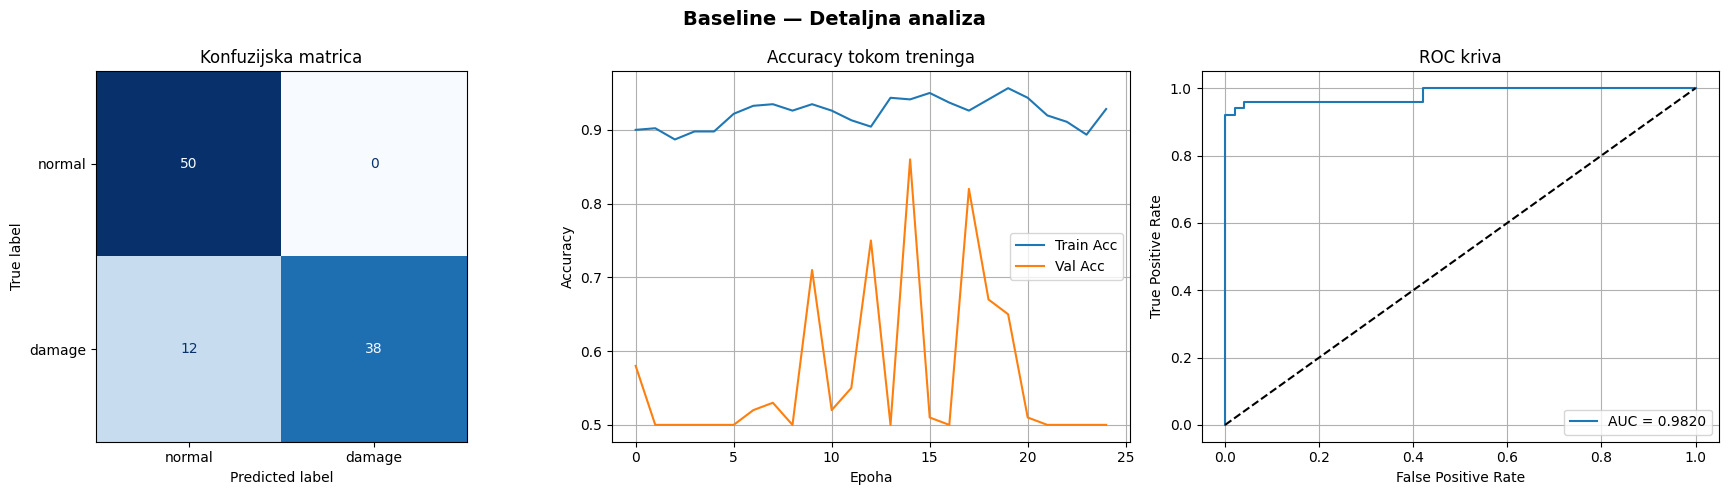


Eksperiment: Adam lr=1e-4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Test Acc: 0.9500  |  AUC: 0.9796  |  Epohe: 30

Eksperiment: SGD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Test Acc: 0.8900  |  AUC: 0.9480  |  Epohe: 30

Eksperiment: RMSprop
  Test Acc: 0.9000  |  AUC: 0.9848  |  Epohe: 30

Eksperiment: Batch=16


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Test Acc: 0.9600  |  AUC: 0.9556  |  Epohe: 30

Eksperiment: Batch=32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Test Acc: 0.9500  |  AUC: 0.9600  |  Epohe: 30

--- FULL METRIKE: Batch=32 ---
              precision    recall  f1-score   support

      normal       0.91      1.00      0.95        50
      damage       1.00      0.90      0.95        50

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100

ROC-AUC: 0.9600


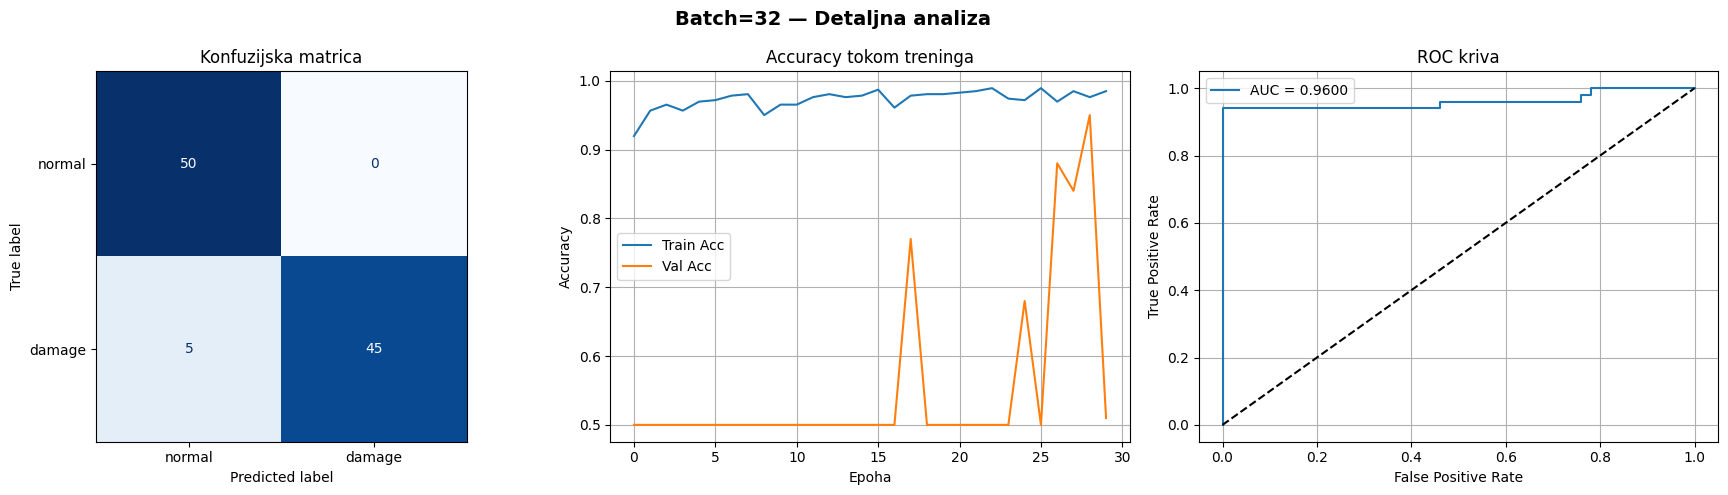


Eksperiment: Dense=64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Test Acc: 0.9200  |  AUC: 0.9668  |  Epohe: 25

Eksperiment: relu activation


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Test Acc: 0.9800  |  AUC: 0.9836  |  Epohe: 23

TABELA REZULTATA
          Naziv Optimizer     LR  Batch  Filters  Dense Conv Act  Test Acc  ROC-AUC  F1 normal  F1 damage  Epohe
       Baseline      ADAM 0.0010      8       16     32     tanh      0.88   0.9820     0.8929     0.8636     25
   Adam lr=1e-4      ADAM 0.0001      8       16     32     tanh      0.95   0.9796     0.9524     0.9474     30
            SGD       SGD 0.0010      8       16     32     tanh      0.89   0.9480     0.9009     0.8764     30
        RMSprop   RMSPROP 0.0010      8       16     32     tanh      0.90   0.9848     0.8936     0.9057     30
       Batch=16      ADAM 0.0010     16       16     32     tanh      0.96   0.9556     0.9615     0.9583     30
       Batch=32      ADAM 0.0010     32       16     32     tanh      0.95   0.9600     0.9524     0.9474     30
       Dense=64      ADAM 0.0010      8       16     64     tanh      0.92   0.9668     0.9259     0.9130     25
relu activation      ADAM 0.0

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

experiments = [
    ("Baseline",        'adam',    1e-3, 8,  16, 32, 'tanh'),
    ("Adam lr=1e-4",    'adam',    1e-4, 8,  16, 32, 'tanh'),
    ("SGD",             'sgd',     1e-3, 8,  16, 32, 'tanh'),
    ("RMSprop",         'rmsprop', 1e-3, 8,  16, 32, 'tanh'),
    ("Batch=16",        'adam',    1e-3, 16, 16, 32, 'tanh'),
    ("Batch=32",        'adam',    1e-3, 32, 16, 32, 'tanh'),
    ("Dense=64",        'adam',    1e-3, 8,  16, 64, 'tanh'),
    ("relu activation", 'adam',    1e-3, 8,  16, 32, 'relu'),
]

# Eksperimenti za koje hoćemo full prikaz
FULL_REPORT_NAMES = {"Baseline", "Batch=32"}

results   = []
histories = {}

for name, opt, lr, bs, filters, dense, conv_act in experiments:
    print(f"\n{'='*50}")
    print(f"Eksperiment: {name}")
    print(f"{'='*50}")

    model = Sequential([
        ConvLSTM2D(
            filters=filters,
            kernel_size=(3, 3),
            activation=conv_act,
            input_shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3),
            return_sequences=False,
            padding='same'
        ),
        BatchNormalization(),
        Flatten(),
        Dense(dense, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.05)),
        BatchNormalization(),
        Dropout(0.6),
        Dense(1, activation='sigmoid')
    ])

    if opt == 'sgd':
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif opt == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=0
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=bs,
        class_weight=class_weight_dict,
        callbacks=[early_stop],
        verbose=0
    )

    histories[name] = history

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    y_proba = model.predict(X_test, verbose=0).flatten()
    y_pred  = (y_proba >= 0.5).astype(int)
    auc     = roc_auc_score(y_test, y_proba)
    report  = classification_report(y_test, y_pred,
                                    target_names=CLASSES_LIST,
                                    output_dict=True)

    results.append({
        'Naziv':     name,
        'Optimizer': opt.upper(),
        'LR':        lr,
        'Batch':     bs,
        'Filters':   filters,
        'Dense':     dense,
        'Conv Act':  conv_act,
        'Test Acc':  round(test_acc, 4),
        'ROC-AUC':   round(auc, 4),
        'F1 normal': round(report['normal']['f1-score'], 4),
        'F1 damage': round(report['damage']['f1-score'], 4),
        'Epohe':     len(history.history['loss'])
    })

    print(f"  Test Acc: {test_acc:.4f}  |  AUC: {auc:.4f}  |  Epohe: {len(history.history['loss'])}")

    # ── Full metrike samo za Baseline i Batch=32 ───────────────
    if name in FULL_REPORT_NAMES:
        print(f"\n--- FULL METRIKE: {name} ---")
        print(classification_report(y_test, y_pred, target_names=CLASSES_LIST))
        print(f"ROC-AUC: {auc:.4f}")

        # Konfuzijska matrica
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f"{name} — Detaljna analiza", fontsize=14, fontweight='bold')

        # 1. Konfuzijska matrica
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES_LIST)
        disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
        axes[0].set_title("Konfuzijska matrica")

        # 2. Train vs Val accuracy
        axes[1].plot(history.history['accuracy'],     label='Train Acc')
        axes[1].plot(history.history['val_accuracy'], label='Val Acc')
        axes[1].set_title("Accuracy tokom treninga")
        axes[1].set_xlabel("Epoha")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
        axes[1].grid(True)

        # 3. ROC kriva
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        axes[2].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
        axes[2].plot([0, 1], [0, 1], 'k--')
        axes[2].set_title("ROC kriva")
        axes[2].set_xlabel("False Positive Rate")
        axes[2].set_ylabel("True Positive Rate")
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

# ── Tabela rezultata ───────────────────────────────────────────
df = pd.DataFrame(results)
print("\n" + "="*80)
print("TABELA REZULTATA")
print("="*80)
print(df.to_string(index=False))

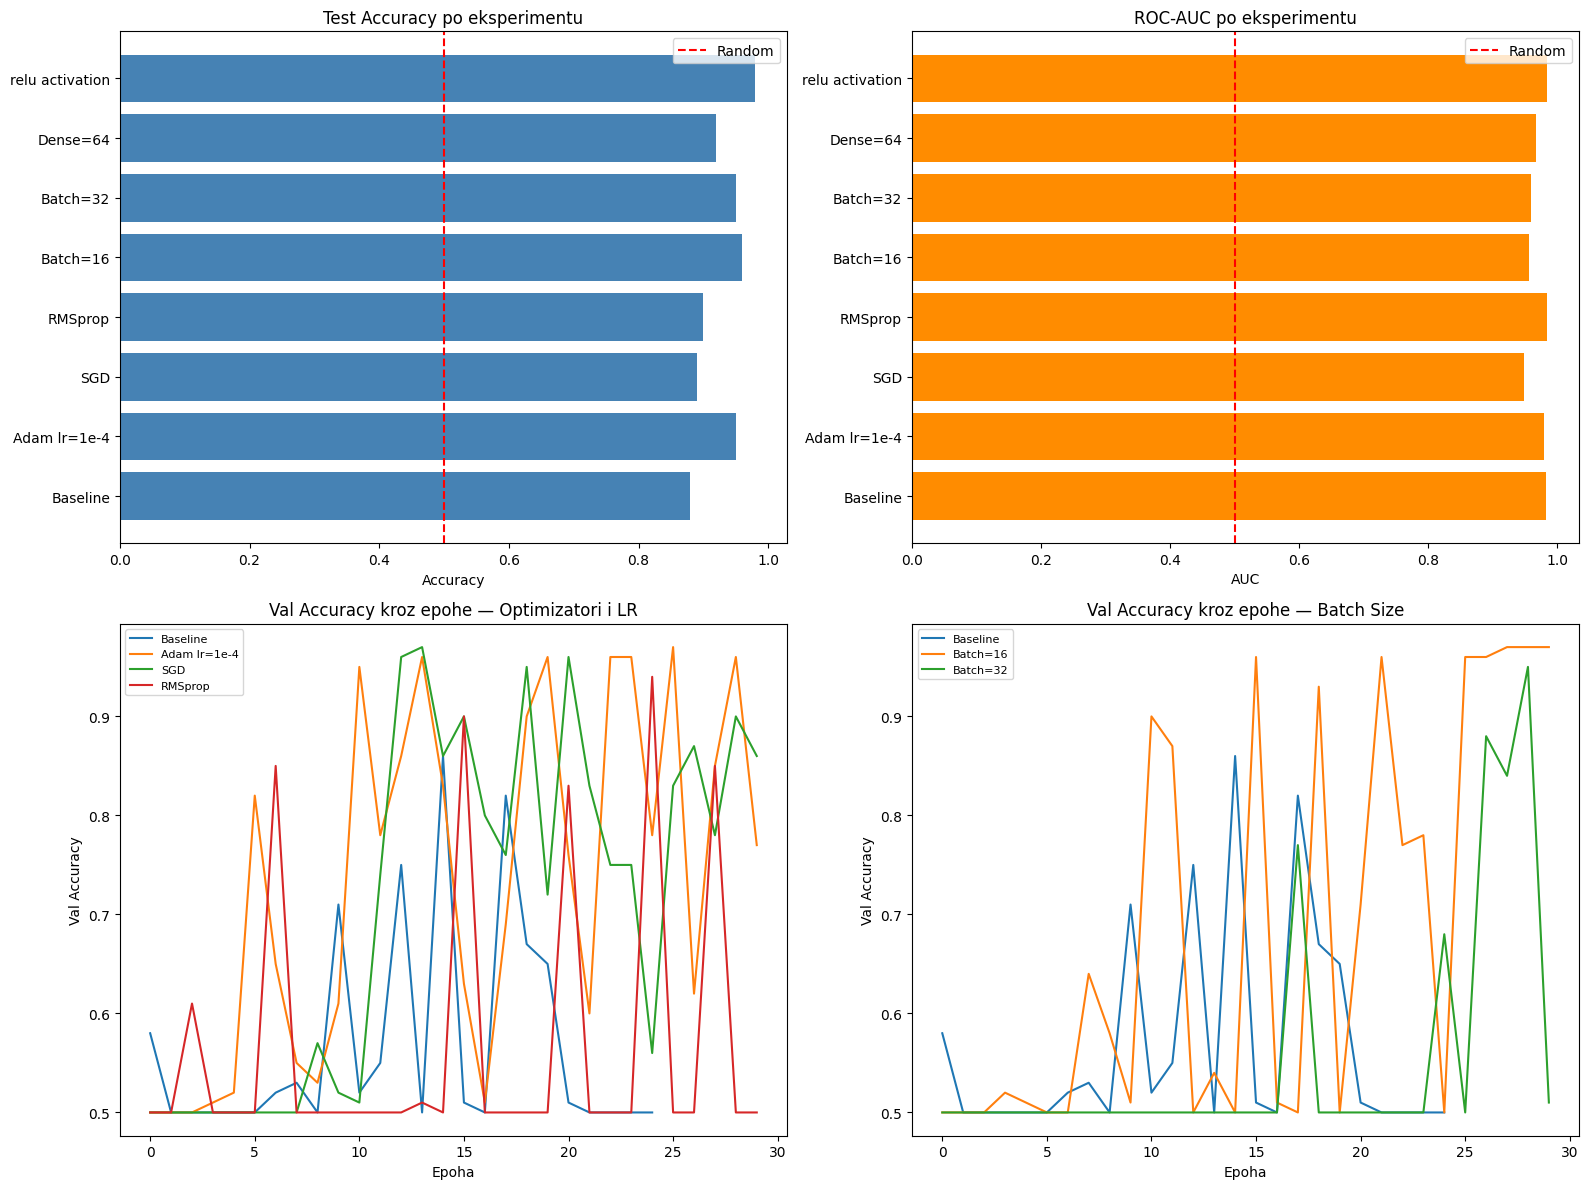

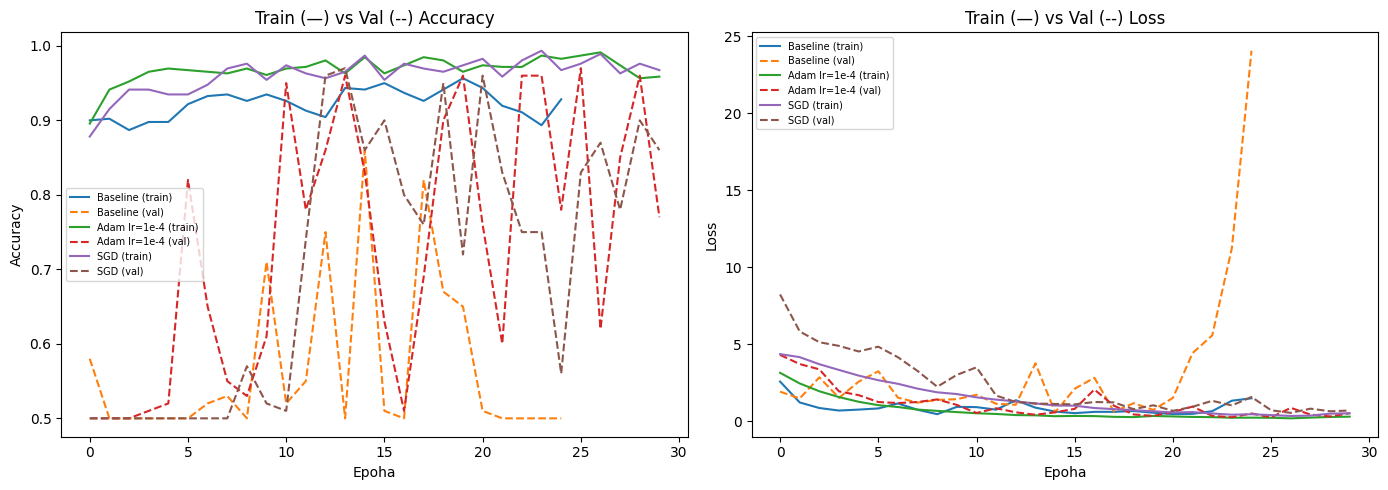

Grafovi sačuvani na Drive.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graf 1: Test Accuracy
axes[0,0].barh(df['Naziv'], df['Test Acc'], color='steelblue')
axes[0,0].axvline(x=0.5, color='red', linestyle='--', label='Random')
axes[0,0].set_title('Test Accuracy po eksperimentu')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].legend()

# Graf 2: ROC-AUC
axes[0,1].barh(df['Naziv'], df['ROC-AUC'], color='darkorange')
axes[0,1].axvline(x=0.5, color='red', linestyle='--', label='Random')
axes[0,1].set_title('ROC-AUC po eksperimentu')
axes[0,1].set_xlabel('AUC')
axes[0,1].legend()

# Graf 3: Val accuracy — optimizatori i LR
odabrani = ['Baseline', 'Adam lr=1e-4', 'SGD', 'RMSprop']
for name in odabrani:
    if name in histories:
        axes[1,0].plot(histories[name].history['val_accuracy'], label=name)
axes[1,0].set_title('Val Accuracy kroz epohe — Optimizatori i LR')
axes[1,0].set_xlabel('Epoha')
axes[1,0].set_ylabel('Val Accuracy')
axes[1,0].legend(fontsize=8)

# Graf 4: Val accuracy — batch size
odabrani_batch = ['Baseline', 'Batch=16', 'Batch=32']
for name in odabrani_batch:
    if name in histories:
        axes[1,1].plot(histories[name].history['val_accuracy'], label=name)
axes[1,1].set_title('Val Accuracy kroz epohe — Batch Size')
axes[1,1].set_xlabel('Epoha')
axes[1,1].set_ylabel('Val Accuracy')
axes[1,1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/eksperimenti_usporedba.png', dpi=150)
plt.show()

# Graf 5: Train vs Val
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

for name in ['Baseline', 'Adam lr=1e-4', 'SGD']:
    if name in histories:
        axes2[0].plot(histories[name].history['accuracy'],
                      label=f'{name} (train)', linestyle='-')
        axes2[0].plot(histories[name].history['val_accuracy'],
                      label=f'{name} (val)', linestyle='--')
axes2[0].set_title('Train (—) vs Val (--) Accuracy')
axes2[0].set_xlabel('Epoha')
axes2[0].set_ylabel('Accuracy')
axes2[0].legend(fontsize=7)

for name in ['Baseline', 'Adam lr=1e-4', 'SGD']:
    if name in histories:
        axes2[1].plot(histories[name].history['loss'],
                      label=f'{name} (train)', linestyle='-')
        axes2[1].plot(histories[name].history['val_loss'],
                      label=f'{name} (val)', linestyle='--')
axes2[1].set_title('Train (—) vs Val (--) Loss')
axes2[1].set_xlabel('Epoha')
axes2[1].set_ylabel('Loss')
axes2[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/train_vs_val_usporedba.png', dpi=150)
plt.show()

print("Grafovi sačuvani na Drive.")

              precision    recall  f1-score   support

      normal       0.96      1.00      0.98        50
      damage       1.00      0.96      0.98        50

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100

ROC-AUC: 0.9836


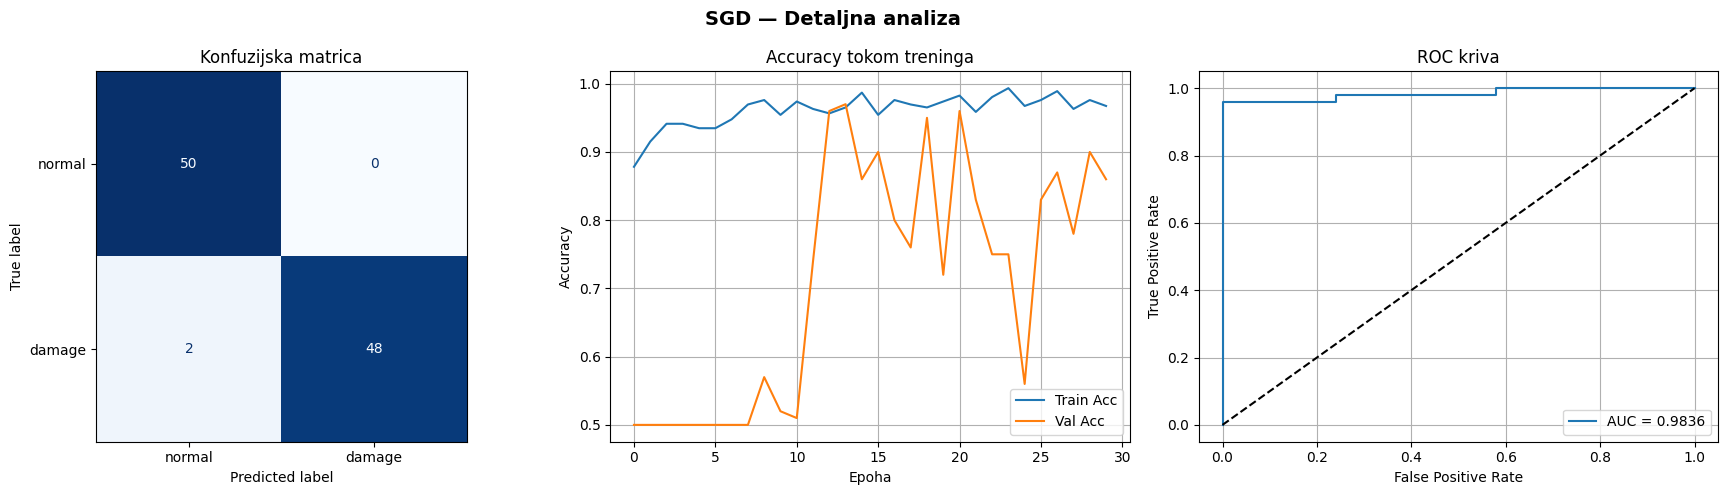

In [ ]:
# Odaberi koji eksperiment hoćeš
name = "SGD"  # ili "Batch=32"

y_proba  = model.predict(X_test, verbose=0).flatten()  # ako model nije overwritan
y_pred   = (y_proba >= 0.5).astype(int)
auc      = roc_auc_score(y_test, y_proba)
history  = histories[name]

print(classification_report(y_test, y_pred, target_names=CLASSES_LIST))
print(f"ROC-AUC: {auc:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"{name} — Detaljna analiza", fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES_LIST)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Konfuzijska matrica")

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title("Accuracy tokom treninga")
axes[1].set_xlabel("Epoha")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[2].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_title("ROC kriva")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

      normal       0.96      1.00      0.98        50
      damage       1.00      0.96      0.98        50

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100

ROC-AUC: 0.9836


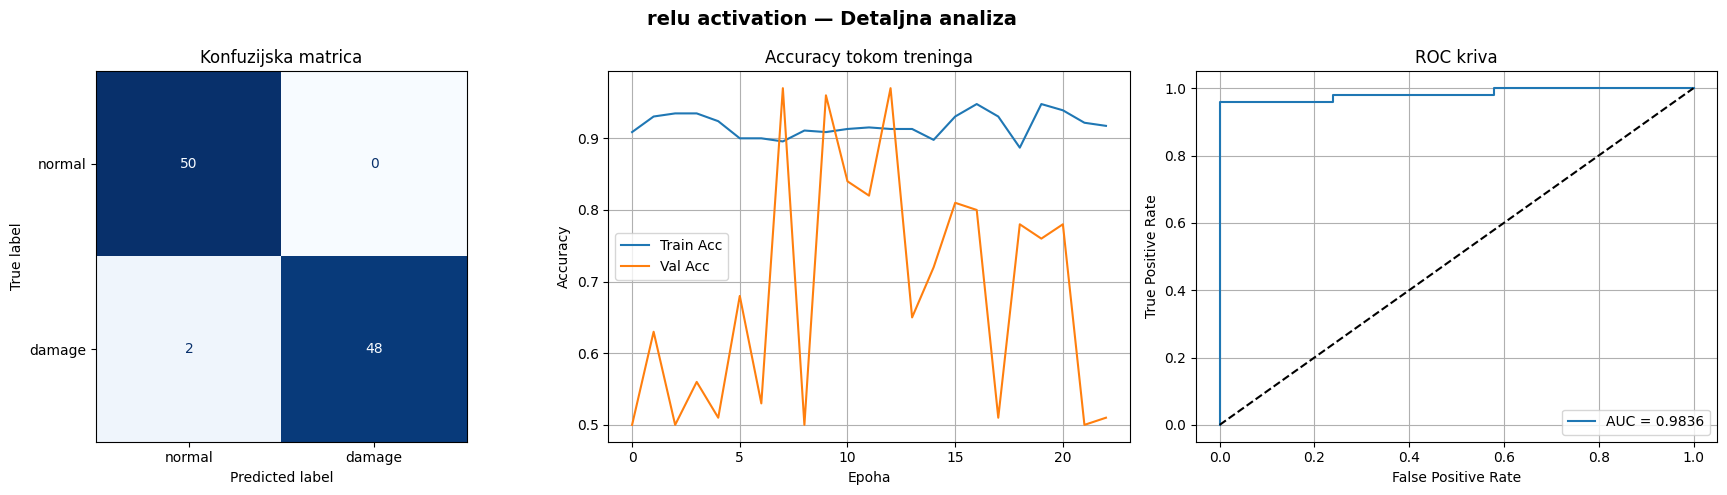

In [ ]:
# Odaberi koji eksperiment hoćeš
name = "relu activation"  # ili "Batch=32"

y_proba  = model.predict(X_test, verbose=0).flatten()  # ako model nije overwritan
y_pred   = (y_proba >= 0.5).astype(int)
auc      = roc_auc_score(y_test, y_proba)
history  = histories[name]

print(classification_report(y_test, y_pred, target_names=CLASSES_LIST))
print(f"ROC-AUC: {auc:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"{name} — Detaljna analiza", fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES_LIST)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Konfuzijska matrica")

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title("Accuracy tokom treninga")
axes[1].set_xlabel("Epoha")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[2].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_title("ROC kriva")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

      normal       0.96      1.00      0.98        50
      damage       1.00      0.96      0.98        50

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100

ROC-AUC: 0.9836


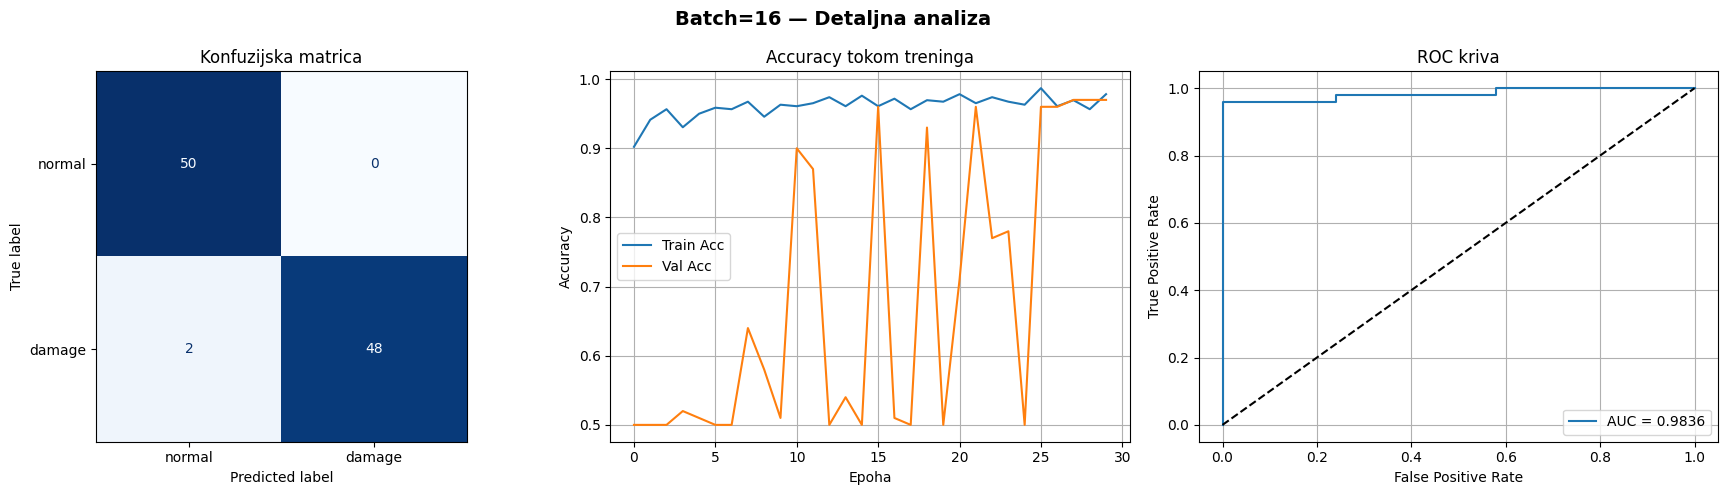

In [ ]:
# Odaberi koji eksperiment hoćeš
name = "Batch=16"  # ili "Batch=32"

y_proba  = model.predict(X_test, verbose=0).flatten()  # ako model nije overwritan
y_pred   = (y_proba >= 0.5).astype(int)
auc      = roc_auc_score(y_test, y_proba)
history  = histories[name]

print(classification_report(y_test, y_pred, target_names=CLASSES_LIST))
print(f"ROC-AUC: {auc:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"{name} — Detaljna analiza", fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES_LIST)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Konfuzijska matrica")

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title("Accuracy tokom treninga")
axes[1].set_xlabel("Epoha")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[2].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_title("ROC kriva")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, TimeDistributed, GlobalAveragePooling2D,
    LSTM, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ── Model ─────────────────────────────────────────────────────
base_model = MobileNetV2(
    input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = Input(shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3))
x = TimeDistributed(base_model)(inputs)
x = TimeDistributed(GlobalAveragePooling2D())(x)
x = LSTM(64, return_sequences=False)(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(1, activation='sigmoid')(x)

model_mobile = Model(inputs, outputs)

model_mobile.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_mobile.summary()

# ── Treniranje ─────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

print("\n[INFO] Počinjem treniranje MobileNetV2...")
history_mobile = model_mobile.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=8,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

# ── Evaluacija ─────────────────────────────────────────────────
test_loss, test_acc = model_mobile.evaluate(X_test, y_test, verbose=0)
print(f"\n  Test Loss:     {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.4f}")

y_proba = model_mobile.predict(X_test, verbose=0).flatten()
y_pred  = (y_proba >= 0.5).astype(int)
auc     = roc_auc_score(y_test, y_proba)

print("\n[METRIKE] Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASSES_LIST))
print(f"[METRIKE] ROC-AUC: {auc:.4f}")

cm = confusion_matrix(y_test, y_pred)
print(f"[METRIKE] Confusion Matrix:\n{cm}")

/tmp/ipykernel_335/2903922522.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 20, 64, 64, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 20, 2, 2, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 20, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │       344,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,604,673 (9.94 MB)

 Trainable params: 346,561 (1.32 MB)

 Non-trainable params: 2,258,112 (8.61 MB)


[INFO] Počinjem treniranje MobileNetV2...
Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 118s 604ms/step - accuracy: 0.5804 - loss: 0.8889 - val_accuracy: 0.6600 - val_loss: 0.5623
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.7109 - loss: 0.6292 - val_accuracy: 0.7900 - val_loss: 0.4665
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - accuracy: 0.7848 - loss: 0.4667 - val_accuracy: 0.8400 - val_loss: 0.3729
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.8022 - loss: 0.4597 - val_accuracy: 0.9000 - val_loss: 0.2884
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.8543 - loss: 0.3595 - val_accuracy: 0.9000 - val_loss: 0.2401
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.8283 - loss: 0.3864 - val_accuracy: 0.9100 - val_loss: 0.1997
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - accuracy: 0.8587 - loss: 0.3115 - val_accuracy: 0.9100 - val_loss: 0.1784
Epoch 8/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - accur

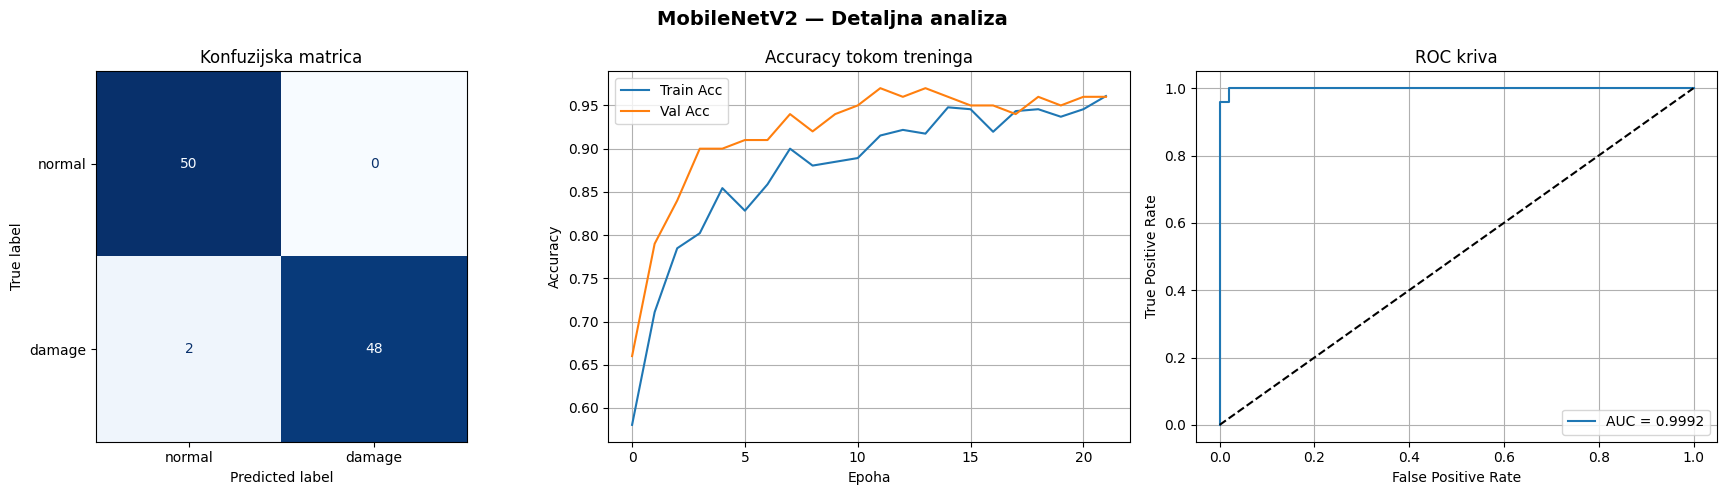

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("MobileNetV2 — Detaljna analiza", fontsize=14, fontweight='bold')

# 1. Konfuzijska matrica
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES_LIST)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Konfuzijska matrica")

# 2. Train vs Val accuracy
axes[1].plot(history_mobile.history['accuracy'],     label='Train Acc')
axes[1].plot(history_mobile.history['val_accuracy'], label='Val Acc')
axes[1].set_title("Accuracy tokom treninga")
axes[1].set_xlabel("Epoha")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

# 3. ROC kriva
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[2].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_title("ROC kriva")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

experiments = [
    # (naziv, optimizer, lr, batch_size, filters, dense, conv_activation)
    ("Baseline",        'adam',    1e-3, 8,  16, 32, 'tanh'),
    ("Adam lr=1e-4",    'adam',    1e-4, 8,  16, 32, 'tanh'),
    ("SGD",             'sgd',     1e-3, 8,  16, 32, 'tanh'),
    ("RMSprop",         'rmsprop', 1e-3, 8,  16, 32, 'tanh'),
    ("Batch=16",        'adam',    1e-3, 16, 16, 32, 'tanh'),
    ("Batch=32",        'adam',    1e-3, 32, 16, 32, 'tanh'),
    ("Dense=64",        'adam',    1e-3, 8,  16, 64, 'tanh'),
    ("relu activation", 'adam',    1e-3, 8,  16, 32, 'relu'),
]

results    = []
histories  = {}
saved_proba = {}

for name, opt, lr, bs, filters, dense, conv_act in experiments:
    print(f"\n{'='*50}")
    print(f"Eksperiment: {name}")
    print(f"{'='*50}")

    model = Sequential([
        ConvLSTM2D(
            filters=filters,
            kernel_size=(3, 3),
            activation=conv_act,
            input_shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3),
            return_sequences=False,
            padding='same'
        ),
        BatchNormalization(),
        Flatten(),
        Dense(dense, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.05)),
        BatchNormalization(),
        Dropout(0.6),
        Dense(1, activation='sigmoid')
    ])

    if opt == 'sgd':
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif opt == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=0
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=bs,
        class_weight=class_weight_dict,
        callbacks=[early_stop],
        verbose=0
    )

    histories[name] = history

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    y_proba = model.predict(X_test, verbose=0).flatten()
    y_pred  = (y_proba >= 0.5).astype(int)
    auc     = roc_auc_score(y_test, y_proba)
    report  = classification_report(y_test, y_pred,
                                    target_names=CLASSES_LIST,
                                    output_dict=True)

    saved_proba[name] = y_proba

    results.append({
        'Naziv':     name,
        'Optimizer': opt.upper(),
        'LR':        lr,
        'Batch':     bs,
        'Filters':   filters,
        'Dense':     dense,
        'Conv Act':  conv_act,
        'Test Acc':  round(test_acc, 4),
        'ROC-AUC':   round(auc, 4),
        'F1 normal': round(report['normal']['f1-score'], 4),
        'F1 damage': round(report['damage']['f1-score'], 4),
        'Epohe':     len(history.history['loss'])
    })

    print(f"\n  Test Acc : {test_acc:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"  Epohe    : {len(history.history['loss'])}")
    print(classification_report(y_test, y_pred, target_names=CLASSES_LIST))

# ── Tabela rezultata ───────────────────────────────────────────
df = pd.DataFrame(results)
print("\n" + "="*80)
print("TABELA REZULTATA — ConvLSTM2D")
print("="*80)
print(df.to_string(index=False))


Eksperiment: Baseline


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



  Test Acc : 0.9100
  ROC-AUC  : 0.9756
  Epohe    : 28
              precision    recall  f1-score   support

      normal       0.85      1.00      0.92        50
      damage       1.00      0.82      0.90        50

    accuracy                           0.91       100
   macro avg       0.92      0.91      0.91       100
weighted avg       0.92      0.91      0.91       100


Eksperiment: Adam lr=1e-4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



  Test Acc : 0.9500
  ROC-AUC  : 0.9748
  Epohe    : 30
              precision    recall  f1-score   support

      normal       0.92      0.98      0.95        50
      damage       0.98      0.92      0.95        50

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100


Eksperiment: SGD


...


  Test Acc : 0.9500
  ROC-AUC  : 0.9816
  Epohe    : 30
              precision    recall  f1-score   support

      normal       0.91      1.00      0.95        50
      damage       1.00      0.90      0.95        50

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100


Eksperiment: Dense=64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



  Test Acc : 0.9700
  ROC-AUC  : 0.9712
  Epohe    : 30
              precision    recall  f1-score   support

      normal       0.94      1.00      0.97        50
      damage       1.00      0.94      0.97        50

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100


Eksperiment: relu activation


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



  Test Acc : 0.9600
  ROC-AUC  : 0.9892
  Epohe    : 25
              precision    recall  f1-score   support

      normal       0.93      1.00      0.96        50
      damage       1.00      0.92      0.96        50

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100


TABELA REZULTATA — ConvLSTM2D
          Naziv Optimizer     LR  Batch  Filters  Dense Conv Act  Test Acc  ROC-AUC  F1 normal  F1 damage  Epohe
       Baseline      ADAM 0.0010      8       16     32     tanh      0.91   0.9756     0.9174     0.9011     28
   Adam lr=1e-4      ADAM 0.0001      8       16     32     tanh      0.95   0.9748     0.9515     0.9485     30
            SGD       SGD 0.0010      8       16     32     tanh      0.94   0.9520     0.9434     0.9362     30
        RMSprop   RMSPROP 0.0010      8       16     32     tanh      0.98   0.9884     0.9804     0.9796     25
       Batch=16     

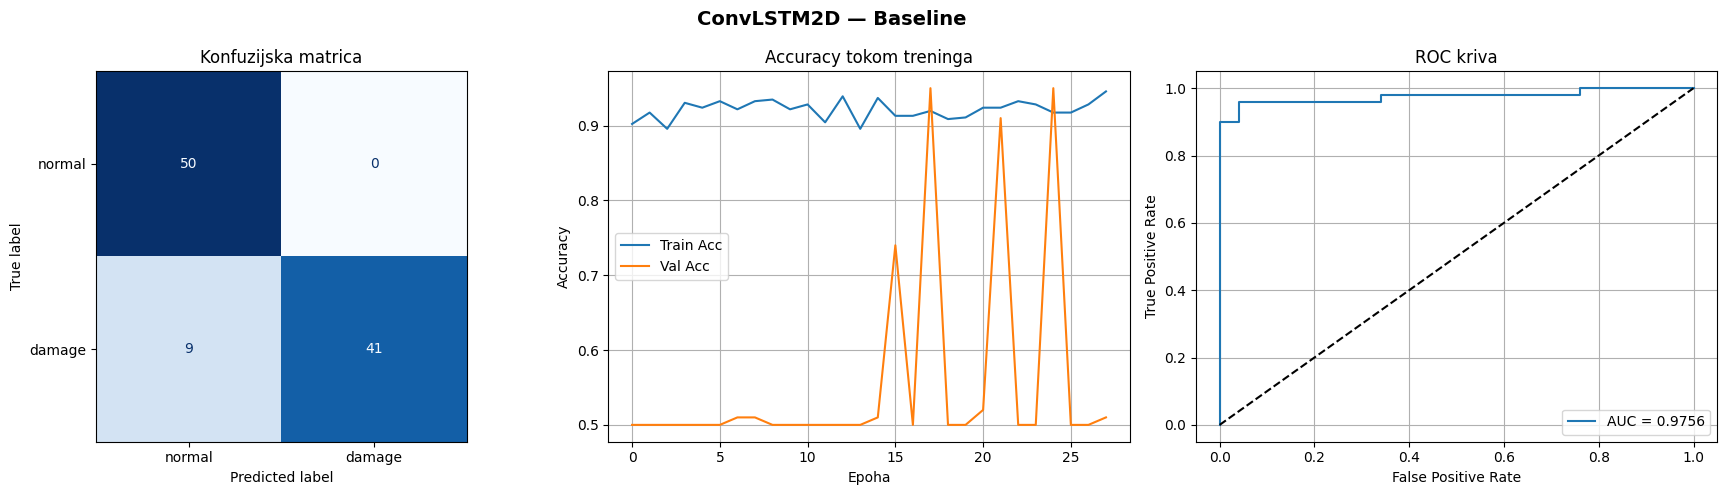

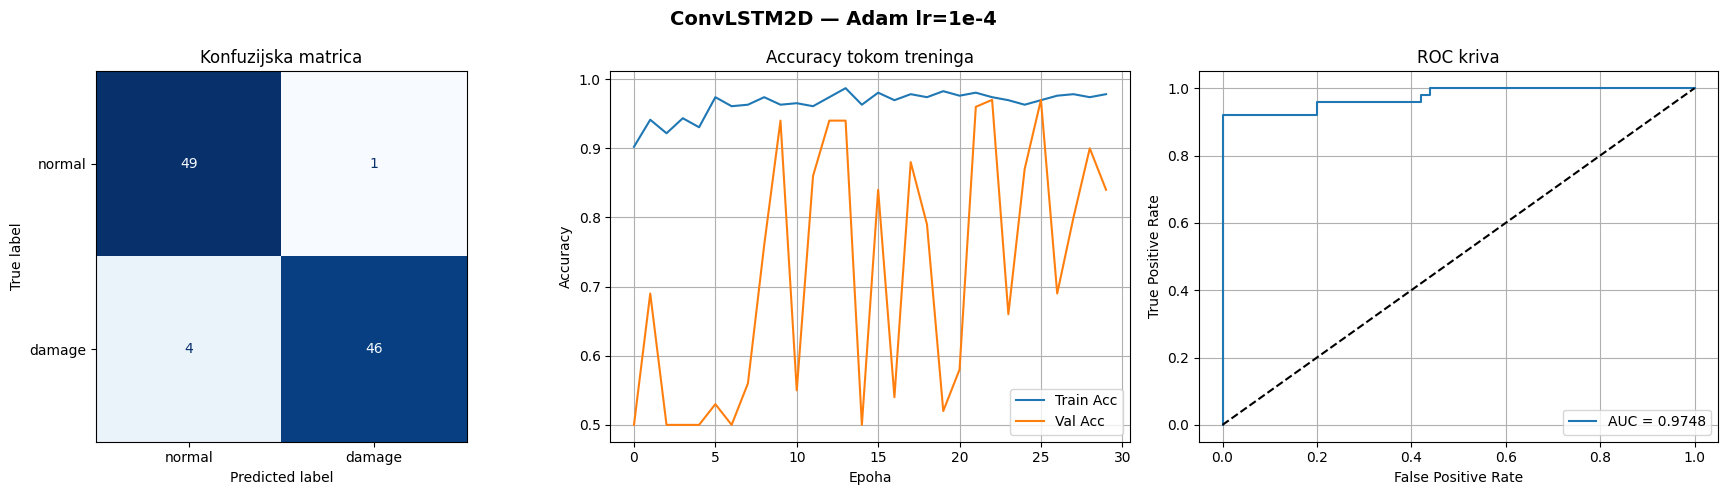

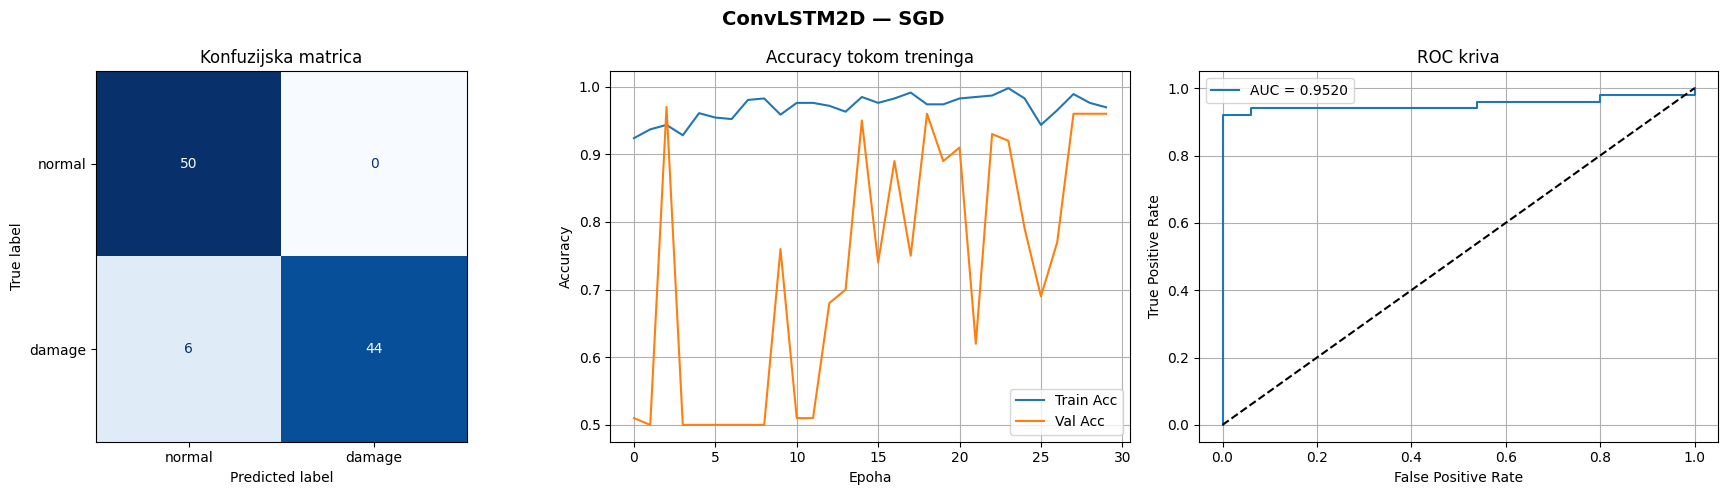

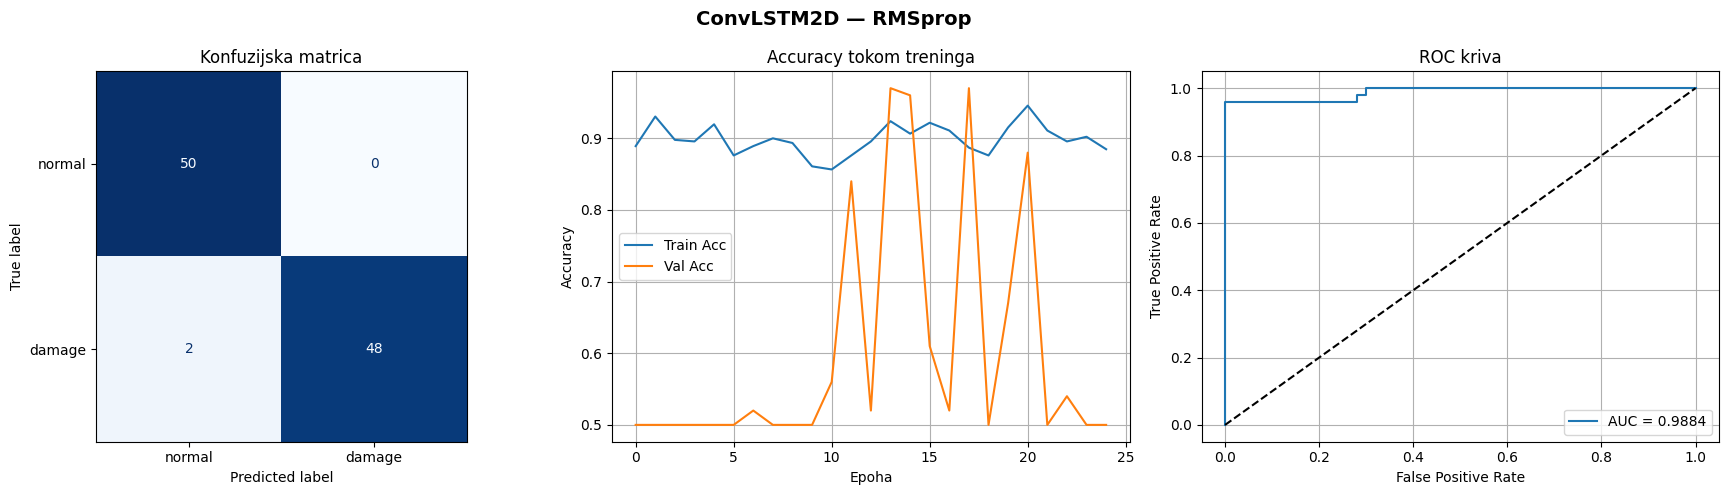

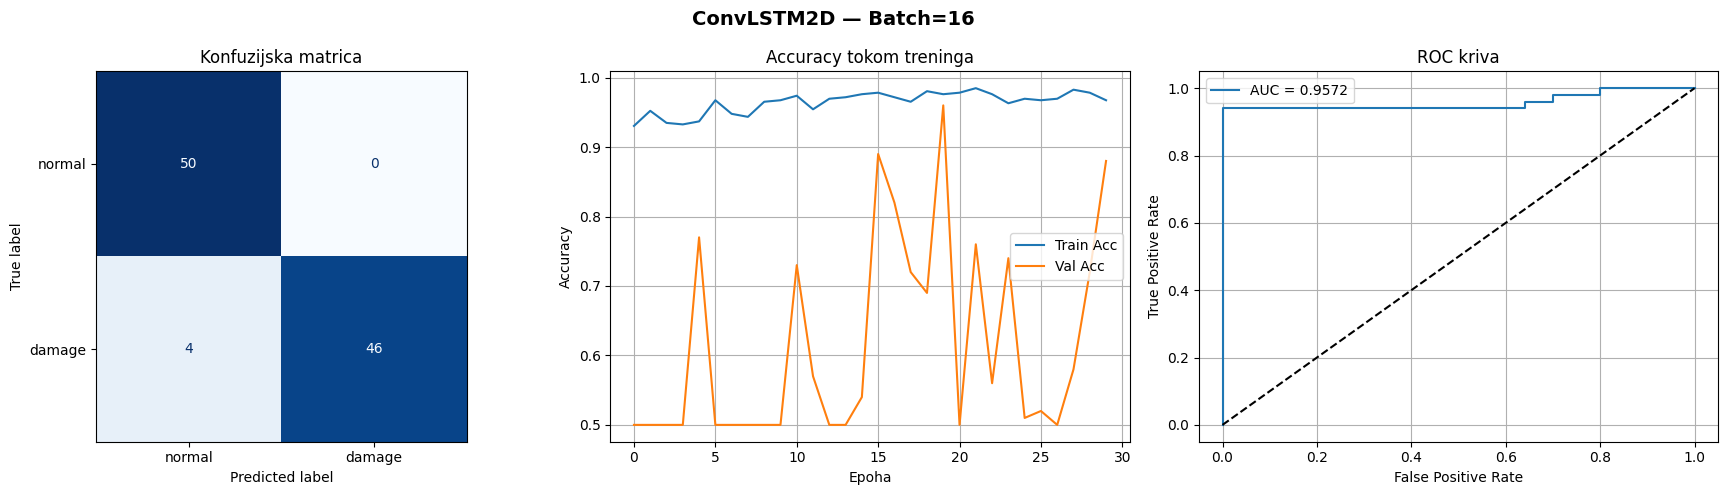

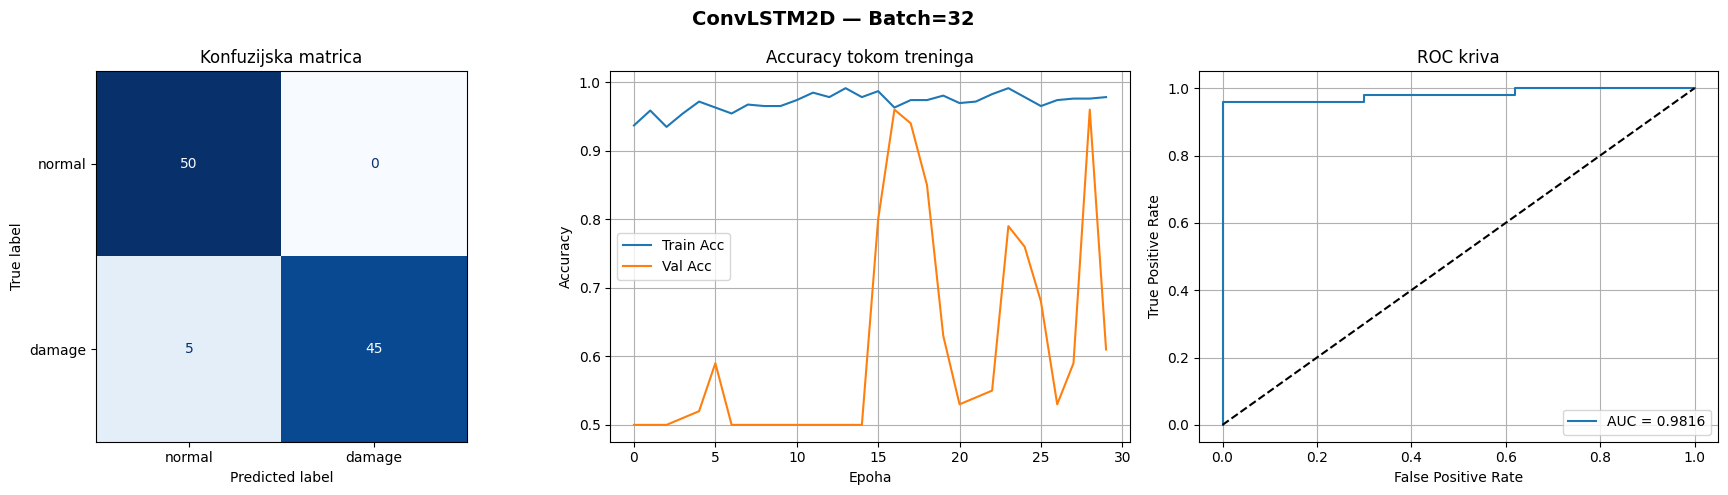

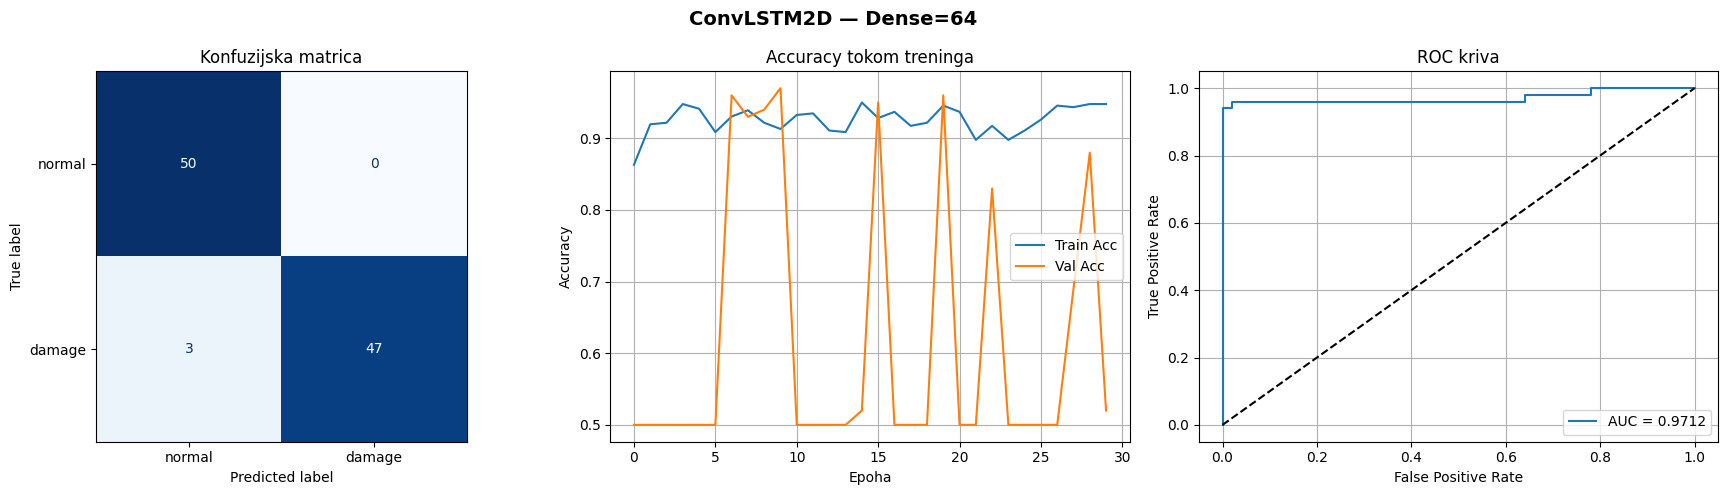

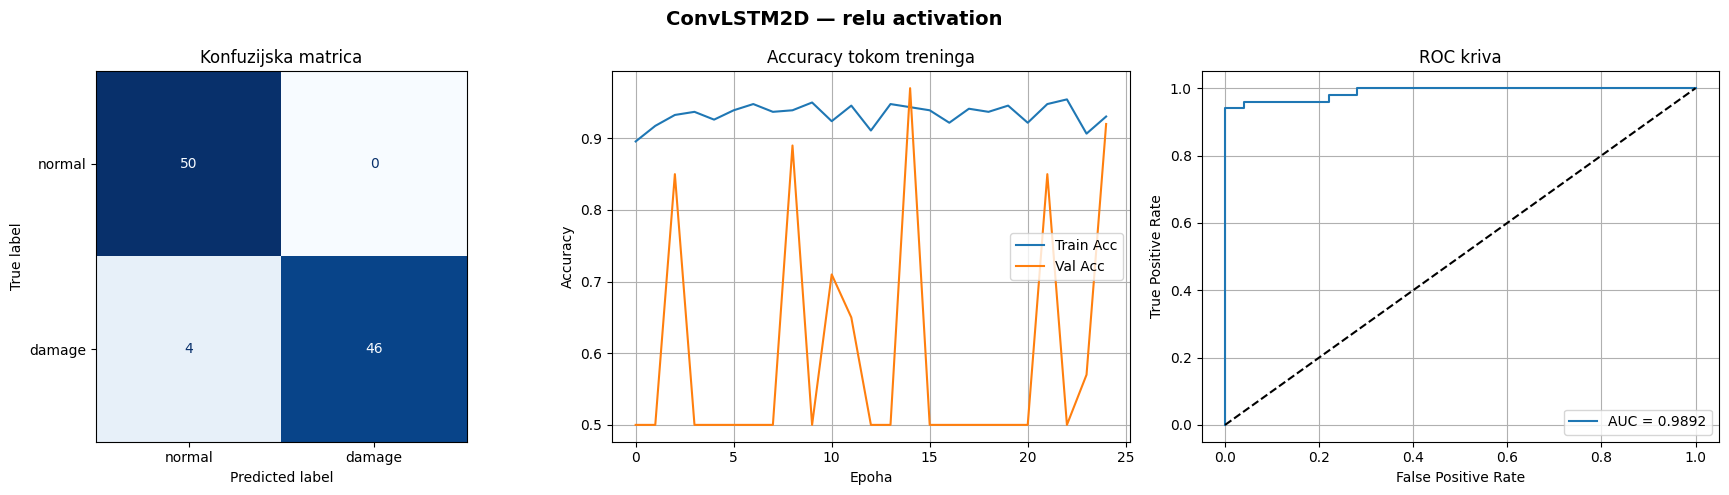

In [ ]:
for name in ["Baseline", "Adam lr=1e-4", "SGD", "RMSprop",
             "Batch=16", "Batch=32", "Dense=64", "relu activation"]:

    y_proba = saved_proba[name]
    y_pred  = (y_proba >= 0.5).astype(int)
    auc     = roc_auc_score(y_test, y_proba)
    history = histories[name]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"ConvLSTM2D — {name}", fontsize=14, fontweight='bold')

    # 1. Konfuzijska matrica
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES_LIST)
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title("Konfuzijska matrica")

    # 2. Accuracy krive
    axes[1].plot(history.history['accuracy'],     label='Train Acc')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc')
    axes[1].set_title("Accuracy tokom treninga")
    axes[1].set_xlabel("Epoha")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    # 3. ROC kriva
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[2].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    axes[2].plot([0, 1], [0, 1], 'k--')
    axes[2].set_title("ROC kriva")
    axes[2].set_xlabel("False Positive Rate")
    axes[2].set_ylabel("True Positive Rate")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, TimeDistributed, GlobalAveragePooling2D,
    LSTM, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

os.makedirs('/content/drive/MyDrive/models_mobile', exist_ok=True)

experiments_mobile = [
    # (naziv, optimizer, lr, batch_size, lstm_units, dense_units)
    ("Baseline",    'adam',    1e-3, 8,  64, 32),
    ("Adam lr=1e-4",'adam',    1e-4, 8,  64, 32),
    ("SGD",         'sgd',     1e-3, 8,  64, 32),
    ("RMSprop",     'rmsprop', 1e-3, 8,  64, 32),
    ("Batch=16",    'adam',    1e-4, 16, 64, 32),
    ("LSTM=128",    'adam',    1e-4, 8, 128, 32),
    ("Dense=64",    'adam',    1e-4, 8,  64, 64),
]

results_mobile    = []
histories_mobile  = {}
saved_proba_mobile = {}

for name, opt, lr, bs, lstm_units, dense_units in experiments_mobile:
    print(f"\n{'='*50}")
    print(f"Eksperiment: {name}")
    print(f"{'='*50}")

    base_model = MobileNetV2(
        input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = Input(shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3))
    x = TimeDistributed(base_model)(inputs)
    x = TimeDistributed(GlobalAveragePooling2D())(x)
    x = LSTM(lstm_units, return_sequences=False)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(dense_units, activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model_mobile = Model(inputs, outputs)

    if opt == 'sgd':
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif opt == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model_mobile.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=0
    )

    history = model_mobile.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=bs,
        class_weight=class_weight_dict,
        callbacks=[early_stop],
        verbose=0
    )

    histories_mobile[name] = history

    test_loss, test_acc = model_mobile.evaluate(X_test, y_test, verbose=0)
    y_proba = model_mobile.predict(X_test, verbose=0).flatten()
    y_pred  = (y_proba >= 0.5).astype(int)
    auc     = roc_auc_score(y_test, y_proba)
    report  = classification_report(y_test, y_pred,
                                    target_names=CLASSES_LIST,
                                    output_dict=True)

    saved_proba_mobile[name] = y_proba

    # Snimi model i predikcije
    safe_name = name.replace("=","_").replace(" ","_")
    model_mobile.save(f'/content/drive/MyDrive/models_mobile/{safe_name}_model.keras')
    np.save(f'/content/drive/MyDrive/models_mobile/{safe_name}_y_proba.npy', y_proba)

    results_mobile.append({
        'Naziv':      name,
        'Optimizer':  opt.upper(),
        'LR':         lr,
        'Batch':      bs,
        'LSTM units': lstm_units,
        'Dense':      dense_units,
        'Test Acc':   round(test_acc, 4),
        'ROC-AUC':    round(auc, 4),
        'F1 normal':  round(report['normal']['f1-score'], 4),
        'F1 damage':  round(report['damage']['f1-score'], 4),
        'Epohe':      len(history.history['loss'])
    })

    print(f"\n  Test Acc : {test_acc:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"  Epohe    : {len(history.history['loss'])}")
    print(classification_report(y_test, y_pred, target_names=CLASSES_LIST))

# ── Tabela rezultata ───────────────────────────────────────────
df_mobile = pd.DataFrame(results_mobile)
print("\n" + "="*80)
print("TABELA REZULTATA — MobileNetV2")
print("="*80)
print(df_mobile.to_string(index=False))


Eksperiment: Baseline


/tmp/ipykernel_335/2227045838.py:37: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(



  Test Acc : 0.9800
  ROC-AUC  : 0.9952
  Epohe    : 13
              precision    recall  f1-score   support

      normal       0.96      1.00      0.98        50
      damage       1.00      0.96      0.98        50

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100


Eksperiment: Adam lr=1e-4


/tmp/ipykernel_335/2227045838.py:37: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(



  Test Acc : 0.9800
  ROC-AUC  : 0.9984
  Epohe    : 30
              precision    recall  f1-score   support

      normal       0.96      1.00      0.98        50
      damage       1.00      0.96      0.98        50

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100


Eksperiment: SGD


/tmp/ipykernel_335/2227045838.py:37: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [ ]:
# Učitaj sačuvane predikcije
for name in ["Baseline", "Adam_lr_1e-4"]:
    y_proba = np.load(f'/content/drive/MyDrive/models_mobile/{name}_y_proba.npy')
    y_pred  = (y_proba >= 0.5).astype(int)
    auc     = roc_auc_score(y_test, y_proba)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=CLASSES_LIST))
    print(f"  ROC-AUC: {auc:.4f}")

NameError: name 'np' is not defined